# Real-data Christian stance classification

Extends `Toy Tests/NLI.ipynb` (synthetic, cross-encoder NLI demo) to real Reddit
posts loaded via `reddit_helpers.load_subreddit`.

**Approach**: binary `christian` vs `non_christian` classification using
instruction-prefixed embedding similarity to class centroids built from
subreddit-prior weak labels (no manual labeling).

- Centroid sources: `r/Christianity` (christian), `r/atheism` (non_christian)
- Unlabeled: `r/DebateReligion`
- Baseline: cross-encoder NLI

In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.getenv("REDDIT_CODE_DIR"))

import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier

from sentence_transformers import SentenceTransformer, CrossEncoder

from reddit_helpers import *

pd.set_option("display.max_colwidth", 120)
np.set_printoptions(precision=3, suppress=True)

In [2]:
SUBREDDITS     = ["Christianity", "atheism", "DebateReligion"]
N_PER_SUB      = 150
MIN_TEXT_WORDS = 10
RANDOM_SEED    = 42

EMBED_MODEL_NAME  = "BAAI/bge-base-en-v1.5"
EMBED_INSTRUCTION = "Represent this Reddit post for classifying the author's stance toward Christianity: "
EMBED_BATCH_SIZE  = 32

CROSS_ENCODER_MODEL_NAME = "cross-encoder/nli-deberta-v3-base"
N_CROSSENCODER_PER_SUB   = 30

# Subreddit → centroid class (unmapped subreddits are classified but not used to build centroids)
SUBREDDIT_CLASS = {
    "Christianity": "christian",
    "atheism":      "non_christian",
}

# Per-post detail readout
N_POST_DETAIL_SAMPLES    = 6
TOP_K_STANCES            = 2
PRIMARY_SCORE_THRESHOLD  = 0.20
PRIMARY_MARGIN_THRESHOLD = 0.10

In [3]:
def _clean_field(x):
    if x is None:
        return ""
    if isinstance(x, float) and np.isnan(x):
        return ""
    return str(x).strip()


def make_post_text(row):
    selftext = _clean_field(row.get("selftext"))
    if selftext and selftext not in ("[deleted]", "[removed]"):
        return " ".join(selftext.split())
    return ""


def load_pool(subreddit, n=N_PER_SUB, seed=RANDOM_SEED):
    df = load_subreddit(subreddit, load="posts", slim=True, clean=True)
    df = df.copy()
    df["text"] = df.apply(make_post_text, axis=1)
    df = df[df["text"].str.split().str.len() >= MIN_TEXT_WORDS]
    df = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    df["subreddit"] = subreddit
    return df


def embed_texts(model, texts, instruction=EMBED_INSTRUCTION, batch_size=EMBED_BATCH_SIZE):
    prefixed = [instruction + t for t in texts]
    return model.encode(
        prefixed,
        batch_size=batch_size,
        normalize_embeddings=True,
        show_progress_bar=True,
    )


def classify_by_centroid(embeddings, centroid_christian, centroid_non_christian):
    sim_christian = embeddings @ centroid_christian
    sim_non_christian = embeddings @ centroid_non_christian
    stance_score = sim_christian - sim_non_christian
    pred_label = np.where(stance_score >= 0, "christian", "non_christian")
    return pd.DataFrame({
        "sim_christian": sim_christian,
        "sim_non_christian": sim_non_christian,
        "stance_score": stance_score,
        "embed_pred": pred_label,
    })

In [4]:
df_all = pd.concat([load_pool(sub) for sub in SUBREDDITS], ignore_index=True)
df_all["prototype_class"] = df_all["subreddit"].map(SUBREDDIT_CLASS)

print(f"Total posts loaded: {len(df_all)}")
df_all.groupby("subreddit").size()

Total posts loaded: 450


subreddit
Christianity      150
DebateReligion    150
atheism           150
dtype: int64

In [5]:
# ── Embedding model ──────────────────────────────────────────────────────────
print(f"Loading embedding model: {EMBED_MODEL_NAME}")
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

# ── Instruction-prefixed embeddings for all posts ────────────────────────────
all_embeddings = embed_texts(embed_model, df_all["text"].tolist())

# ── Prototype subreddit groupings ─────────────────────────────────────────────
CHRISTIAN_PROTO_SUBS     = ["Christianity"]
NON_CHRISTIAN_PROTO_SUBS = ["atheism"]
AMBIGUOUS_EVAL_SUBS      = ["DebateReligion"]

mask_christian     = df_all["subreddit"].isin(CHRISTIAN_PROTO_SUBS)
mask_non_christian = df_all["subreddit"].isin(NON_CHRISTIAN_PROTO_SUBS)

# ── Build class centroids (normalised) ───────────────────────────────────────
centroid_christian     = all_embeddings[mask_christian].mean(axis=0)
centroid_non_christian = all_embeddings[mask_non_christian].mean(axis=0)
centroid_christian     /= np.linalg.norm(centroid_christian)
centroid_non_christian /= np.linalg.norm(centroid_non_christian)

# ── Classify all posts by centroid similarity ─────────────────────────────────
pred_df = classify_by_centroid(all_embeddings, centroid_christian, centroid_non_christian)
df_all = pd.concat([df_all.reset_index(drop=True), pred_df], axis=1)

# Prior label: known for prototype subs, NaN for ambiguous subs
df_all["prior_label"] = df_all["subreddit"].map(SUBREDDIT_CLASS)

# ── Eval splits ───────────────────────────────────────────────────────────────
eval_unambiguous = df_all[df_all["subreddit"].isin(CHRISTIAN_PROTO_SUBS + NON_CHRISTIAN_PROTO_SUBS)].copy()
eval_ambiguous   = df_all[df_all["subreddit"].isin(AMBIGUOUS_EVAL_SUBS)].copy()

print(f"eval_unambiguous: {len(eval_unambiguous)} posts")
print(f"eval_ambiguous:   {len(eval_ambiguous)} posts")
display(eval_unambiguous.groupby(["subreddit", "embed_pred"]).size().unstack(fill_value=0))

Loading embedding model: BAAI/bge-base-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

eval_unambiguous: 300 posts
eval_ambiguous:   150 posts


embed_pred,christian,non_christian
subreddit,,
Christianity,123,27
atheism,23,127


In [6]:
# ------------------------------------------------------------
# Richer per-label summary (mean/max stance + best hypothesis),
# used for the per-post detail readout below. Operates on the
# hypo_df returned by score_hypothesis_set above.
# ------------------------------------------------------------

def summarize_label_scores(hypo_df):
    grouped = []

    for label, g in hypo_df.groupby("label"):
        g_sorted = g.sort_values("stance_score", ascending=False)
        best = g_sorted.iloc[0]

        mean_stance = float(g["stance_score"].mean())
        max_stance = float(g["stance_score"].max())
        hybrid_score = 0.70 * mean_stance + 0.30 * max_stance

        grouped.append({
            "label": label,
            "hybrid_score": hybrid_score,
            "mean_stance_score": mean_stance,
            "max_stance_score": max_stance,
            "best_hypothesis": str(best["hypothesis"]),
            "best_hypothesis_score": float(best["stance_score"]),
        })

    return (
        pd.DataFrame(grouped)
        .sort_values("hybrid_score", ascending=False)
        .reset_index(drop=True)
    )


def classify_primary_confidence(label_df):
    top = label_df.iloc[0]
    second = label_df.iloc[1]

    top_score = float(top["hybrid_score"])
    margin = float(top["hybrid_score"] - second["hybrid_score"])

    if top_score < PRIMARY_SCORE_THRESHOLD:
        return "low_confidence"

    if margin < PRIMARY_MARGIN_THRESHOLD:
        return "ambiguous"

    return "usable"

In [7]:
# ── Stance hypotheses (shared across NLI and instructor methods) ──────────────
primary_stance_hypotheses = {
    "christian": [
        "The author is a Christian who believes in Jesus Christ as Lord and Savior.",
        "The author holds a Christian faith and accepts the Bible as authoritative.",
        "The author defends Christianity and its core theological claims.",
        "The author believes in God and practices the Christian religion.",
        "The author expresses a personal relationship with Jesus or God.",
    ],
    "non_christian": [
        "The author is an atheist who does not believe in God.",
        "The author rejects religious claims, including Christianity.",
        "The author considers religion to be false or unsupported by evidence.",
        "The author does not believe in the existence of God or Jesus.",
        "The author is skeptical of or critical toward Christian belief.",
    ],
}


def clean_text(text, max_chars=512):
    return " ".join(str(text).split())[:max_chars]


def get_nli_label_indices(cross_encoder):
    """Return {label_name: output_column_index} from model config."""
    id2label = cross_encoder.model.config.id2label
    return {v.lower(): k for k, v in id2label.items()}


def score_hypothesis_set(cross_encoder, label_indices, text, hypothesis_set):
    """
    Score text against every hypothesis in hypothesis_set.
    Returns (hypo_df, best_label) where hypo_df has columns
    [label, hypothesis, entailment, neutral, contradiction, stance_score].
    stance_score = entailment_prob - contradiction_prob.
    """
    pairs, labels, hyps = [], [], []
    for label, hypotheses in hypothesis_set.items():
        for hyp in hypotheses:
            pairs.append([text, hyp])
            labels.append(label)
            hyps.append(hyp)

    probs = cross_encoder.predict(pairs, apply_softmax=True)  # shape (N, 3)
    ent_i = label_indices["entailment"]
    con_i = label_indices["contradiction"]
    neu_i = next(i for i in range(3) if i != ent_i and i != con_i)

    df = pd.DataFrame({
        "label":         labels,
        "hypothesis":    hyps,
        "entailment":    probs[:, ent_i],
        "neutral":       probs[:, neu_i],
        "contradiction": probs[:, con_i],
        "stance_score":  probs[:, ent_i] - probs[:, con_i],
    })
    best_label = df.groupby("label")["stance_score"].mean().idxmax()
    return df, best_label


def predict_cross_encoder_label(cross_encoder, label_indices, text):
    """Binary prediction using primary_stance_hypotheses. Returns (label, mean_stance_score)."""
    hypo_df, best_label = score_hypothesis_set(
        cross_encoder, label_indices, clean_text(text), primary_stance_hypotheses
    )
    score = float(hypo_df.groupby("label")["stance_score"].mean()[best_label])
    return best_label, score

In [8]:
# ------------------------------------------------------------
# Run cross-encoder on a subsample of each eval set (slower than embeddings)
# ------------------------------------------------------------

print(f"Loading cross-encoder model: {CROSS_ENCODER_MODEL_NAME}")
cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL_NAME)
ce_label_indices = get_nli_label_indices(cross_encoder)


def add_cross_encoder_predictions(df, n_sample):
    idx = df.sample(n=min(n_sample, len(df)), random_state=RANDOM_SEED).index
    ce_labels, ce_scores = {}, {}
    for i in idx:
        label, score = predict_cross_encoder_label(cross_encoder, ce_label_indices, df.loc[i, "text"])
        ce_labels[i] = label
        ce_scores[i] = score
    df["ce_pred"] = pd.Series(ce_labels)
    df["ce_score"] = pd.Series(ce_scores)
    return df


eval_unambiguous = add_cross_encoder_predictions(
    eval_unambiguous, N_CROSSENCODER_PER_SUB * len(CHRISTIAN_PROTO_SUBS + NON_CHRISTIAN_PROTO_SUBS)
)
eval_ambiguous = add_cross_encoder_predictions(
    eval_ambiguous, N_CROSSENCODER_PER_SUB * len(AMBIGUOUS_EVAL_SUBS)
)

print(f"Cross-encoder scored: {eval_unambiguous['ce_pred'].notna().sum()} unambiguous, "
      f"{eval_ambiguous['ce_pred'].notna().sum()} ambiguous posts")

Loading cross-encoder model: cross-encoder/nli-deberta-v3-base


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cross-encoder scored: 60 unambiguous, 30 ambiguous posts


## Three additional stance classifiers

Compare three independent methods against the subreddit-prior weak label:

1. **RF (plain embeddings)** — RandomForest trained on non-instruction BGE embeddings to predict subreddit; subreddit → stance proxy.
2. **NLI (hypothesis set)** — CrossEncoder entailment vs contradiction scores against curated stance sentences; classify by mean stance score per class.
3. **Instructor (sentence cosim)** — Instruction-prefixed post embeddings; classify by average cosine similarity to each class's stance sentence embeddings.

In [9]:
# ── Method 1: RF on plain (no-instruction) embeddings ────────────────────────
print("Method 1 — RF on plain embeddings")
print("Computing plain embeddings (no instruction prefix)...")
plain_embeddings = embed_texts(embed_model, df_all["text"].tolist(), instruction="")

mask_train = df_all["subreddit"].isin(CHRISTIAN_PROTO_SUBS + NON_CHRISTIAN_PROTO_SUBS)
X_train = plain_embeddings[mask_train]
y_train = df_all.loc[mask_train, "subreddit"].values

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)

rf_sub_pred = rf.predict(plain_embeddings)  # predicts subreddit name
df_all["rf_pred"] = np.where(np.array(rf_sub_pred) == "Christianity", "christian", "non_christian")

print("\nCross-tab — RF predicted stance vs actual subreddit")
display(pd.crosstab(df_all["subreddit"], df_all["rf_pred"], margins=True))

rf_acc = (
    df_all.loc[mask_train, "prior_label"] == df_all.loc[mask_train, "rf_pred"]
).mean()
print(f"Accuracy vs subreddit-prior (prototype subs): {rf_acc:.2%}")

Method 1 — RF on plain embeddings
Computing plain embeddings (no instruction prefix)...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]


Cross-tab — RF predicted stance vs actual subreddit


rf_pred,christian,non_christian,All
subreddit,,,
Christianity,150,0,150
DebateReligion,56,94,150
atheism,0,150,150
All,206,244,450


Accuracy vs subreddit-prior (prototype subs): 100.00%


In [10]:
# ── Method 2: NLI on all posts via hypothesis set ─────────────────────────────
print("Method 2 — NLI via hypothesis set (scoring all posts; this will take a few minutes)...")
nli_preds, nli_scores = [], []
for text in df_all["text"]:
    label, score = predict_cross_encoder_label(cross_encoder, ce_label_indices, text)
    nli_preds.append(label)
    nli_scores.append(score)

df_all["nli_pred"]  = nli_preds
df_all["nli_score"] = nli_scores

print("\nCross-tab — NLI predicted stance vs actual subreddit")
display(pd.crosstab(df_all["subreddit"], df_all["nli_pred"], margins=True))

nli_acc = (
    df_all.loc[mask_train, "prior_label"] == df_all.loc[mask_train, "nli_pred"]
).mean()
print(f"Accuracy vs subreddit-prior (prototype subs): {nli_acc:.2%}")

Method 2 — NLI via hypothesis set (scoring all posts; this will take a few minutes)...

Cross-tab — NLI predicted stance vs actual subreddit


nli_pred,christian,non_christian,All
subreddit,,,
Christianity,129,21,150
DebateReligion,109,41,150
atheism,84,66,150
All,322,128,450


Accuracy vs subreddit-prior (prototype subs): 65.00%


In [11]:
# ── Method 3: Instructor embeddings → avg cosine sim to stance sentences ──────
print("Method 3 — Instructor embeddings → sentence cosim")

# Embed each class's stance sentences with instruction prefix
sent_embs = {
    label: embed_texts(embed_model, hyps)  # shape (n_hyps, D), rows normalised
    for label, hyps in primary_stance_hypotheses.items()
}

# avg cosim = mean of dot products (embeddings are normalised)
sim_christian     = (all_embeddings @ sent_embs["christian"].T).mean(axis=1)
sim_non_christian = (all_embeddings @ sent_embs["non_christian"].T).mean(axis=1)

df_all["instructor_pred"]  = np.where(sim_christian >= sim_non_christian, "christian", "non_christian")
df_all["instructor_score"] = sim_christian - sim_non_christian

print("\nCross-tab — Instructor predicted stance vs actual subreddit")
display(pd.crosstab(df_all["subreddit"], df_all["instructor_pred"], margins=True))

inst_acc = (
    df_all.loc[mask_train, "prior_label"] == df_all.loc[mask_train, "instructor_pred"]
).mean()
print(f"Accuracy vs subreddit-prior (prototype subs): {inst_acc:.2%}")

# Summary comparison
print("\n── Accuracy summary (prototype subs, vs subreddit-prior) ──")
print(f"  Embed centroid (existing): {(df_all.loc[mask_train,'prior_label'] == df_all.loc[mask_train,'embed_pred']).mean():.2%}")
print(f"  RF plain embeddings:       {rf_acc:.2%}")
print(f"  NLI hypothesis set:        {nli_acc:.2%}")
print(f"  Instructor sentence cosim: {inst_acc:.2%}")

Method 3 — Instructor embeddings → sentence cosim


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Cross-tab — Instructor predicted stance vs actual subreddit


instructor_pred,christian,non_christian,All
subreddit,,,
Christianity,93,57,150
DebateReligion,28,122,150
atheism,21,129,150
All,142,308,450


Accuracy vs subreddit-prior (prototype subs): 74.00%

── Accuracy summary (prototype subs, vs subreddit-prior) ──
  Embed centroid (existing): 83.33%
  RF plain embeddings:       100.00%
  NLI hypothesis set:        65.00%
  Instructor sentence cosim: 74.00%


In [12]:
# ── Misclassified examples — all subs, all methods ───────────────────────────
N_MISS = 4  # examples per (subreddit × method) block

METHODS = [
    ("RF (plain embeddings)",        "rf_pred"),
    ("NLI (hypothesis set)",         "nli_pred"),
    ("Instructor (sentence cosim)",  "instructor_pred"),
]


def print_misclassified(df_wrong, method_name, pred_col, width=90):
    if df_wrong.empty:
        print(f"  (no misclassifications found)")
        return
    for row in df_wrong.itertuples(index=False):
        pred = getattr(row, pred_col)
        print(f"\n  Subreddit : r/{row.subreddit}")
        print(f"  Prior     : {row.prior_label}")
        print(f"  Predicted : {pred}")
        print(f"  Text:")
        print(textwrap.fill(
            clean_text(row.text),
            width=width,
            initial_indent="    ",
            subsequent_indent="    ",
        ))


for sub in CHRISTIAN_PROTO_SUBS + NON_CHRISTIAN_PROTO_SUBS:
    sub_mask = df_all["subreddit"] == sub
    for method_name, pred_col in METHODS:
        wrong = df_all[sub_mask & (df_all[pred_col] != df_all["prior_label"])]
        sample = wrong.sample(n=min(N_MISS, len(wrong)), random_state=RANDOM_SEED)

        print(f"\n{'='*90}")
        print(f"MISCLASSIFIED | {method_name} | r/{sub} ({len(wrong)} of {sub_mask.sum()} wrong)")
        print(f"{'='*90}")
        print_misclassified(sample, method_name, pred_col)


MISCLASSIFIED | RF (plain embeddings) | r/Christianity (0 of 150 wrong)
  (no misclassifications found)

MISCLASSIFIED | NLI (hypothesis set) | r/Christianity (21 of 150 wrong)

  Subreddit : r/Christianity
  Prior     : christian
  Predicted : non_christian
  Text:
    Hello /r/Christianity! I am an Agnostic Atheist in Charlotte, NC and am looking to
    have a somewhat formal conversation with an apologetic group/Christian group/Open-
    minded Church. I reached out to a prominent apologist the other day to ask if there
    can be meaningful dialogues between staunch Atheists and Theists. He recommended that
    I reach out to local groups/churches if I wanted to make this happen. To clarify, I am
    100% not looking to do a formal debate or hostile questioning session. I want to be
    more o

  Subreddit : r/Christianity
  Prior     : christian
  Predicted : non_christian
  Text:
    So lately I've gotten more and more distant from God and more into sin and recently
    I've bee

In [13]:
# ------------------------------------------------------------
# Per-post detail readout
#
# Random sample of posts across the unambiguous (Christianity/atheism) and
# ambiguous (DebateReligion) eval sets. For each post, recompute the full
# cross-encoder primary-stance ranking (hybrid/mean/max + best hypothesis per
# label) and print a readable summary alongside the gold (subreddit-prior)
# label, when available.
# ------------------------------------------------------------

detail_cols = ["id", "author", "subreddit", "text", "prior_label", "embed_pred", "stance_score"]
df_detail_pool = pd.concat([eval_unambiguous[detail_cols], eval_ambiguous[detail_cols]], ignore_index=True)
df_sample = df_detail_pool.sample(n=N_POST_DETAIL_SAMPLES, random_state=RANDOM_SEED)


def print_post_detail(row, label_df, pred_top1, pred_top2, top1_correct, top2_contains_gold, confidence, margin):
    width = 100
    gold = row.prior_label
    has_gold = pd.notna(gold)

    print("=" * width)
    print(f"Post:       {row.id}")
    print(f"User:       {row.author}")
    print(f"Subreddit:  r/{row.subreddit}")
    print()

    if has_gold:
        print(f"Gold primary stance:      {gold}")
    else:
        print("Gold primary stance:      n/a (no prior)")

    print(f"Pred top-1 stance:        {pred_top1}")
    print(f"Pred top-2 stances:       {pred_top2}")

    if has_gold:
        print(f"Top-1 correct:            {top1_correct}")
        print(f"Top-2 contains gold:      {top2_contains_gold}")

    print(f"Confidence:               {confidence}")
    print(f"Margin:                   {margin:.3f}")
    print()

    print("Text:")
    print(textwrap.fill(clean_text(row.text), width=width))
    print()

    print("Primary stance ranking:")
    for i, r in enumerate(label_df.head(TOP_K_STANCES).itertuples(index=False), start=1):
        pred_marker = "<-- top1" if r.label == pred_top1 else ""
        top2_marker = "<-- top2" if r.label in pred_top2 and r.label != pred_top1 else ""
        gold_marker = "<-- gold" if has_gold and r.label == gold else ""

        print(
            f"  {i}. {r.label:20s} "
            f"hybrid={r.hybrid_score: .3f} | "
            f"mean={r.mean_stance_score: .3f} | "
            f"max={r.max_stance_score: .3f} "
            f"{pred_marker} {top2_marker} {gold_marker}"
        )
        print(f"     best hypothesis: {r.best_hypothesis}")

    print()


for row in df_sample.itertuples(index=False):
    hypo_df, _ = score_hypothesis_set(cross_encoder, ce_label_indices, clean_text(row.text), primary_stance_hypotheses)
    label_df = summarize_label_scores(hypo_df)

    pred_top1 = label_df.iloc[0]["label"]
    pred_top2 = label_df["label"].head(TOP_K_STANCES).tolist()
    margin = float(label_df.iloc[0]["hybrid_score"] - label_df.iloc[1]["hybrid_score"])
    confidence = classify_primary_confidence(label_df)

    gold = row.prior_label
    top1_correct = (pred_top1 == gold) if pd.notna(gold) else None
    top2_contains_gold = (gold in pred_top2) if pd.notna(gold) else None

    print_post_detail(row, label_df, pred_top1, pred_top2, top1_correct, top2_contains_gold, confidence, margin)

Post:       1gvly5
User:       HKfCA
Subreddit:  r/DebateReligion

Gold primary stance:      n/a (no prior)
Pred top-1 stance:        non_christian
Pred top-2 stances:       ['non_christian', 'christian']
Confidence:               usable
Margin:                   0.810

Text:
I think Jesus, or Buddha would be the first ones to go. One smack of Thor's hammer is probably all
it will take. Poseidon vs Pele, Kali vs Athena, Thor vs Hercules, Odin vs Zeus, Holy Ghost vs.
Brahma, Lucifer vs. Mictlantecuhtli, Fugin vs Ehecatl...?

Primary stance ranking:
  1. non_christian        hybrid= 0.671 | mean= 0.536 | max= 0.985 <-- top1  
     best hypothesis: The author is skeptical of or critical toward Christian belief.
  2. christian            hybrid=-0.139 | mean=-0.200 | max= 0.002  <-- top2 
     best hypothesis: The author is a Christian who believes in Jesus Christ as Lord and Savior.

Post:       21ln73
User:       basisvector
Subreddit:  r/DebateReligion

Gold primary stance:      n/a (no

EMBEDDING CLASSIFIER vs SUBREDDIT-PRIOR (unambiguous subs)


embed_pred,christian,non_christian
prior_label,,
christian,123,27
non_christian,23,127


Accuracy: 83.33%


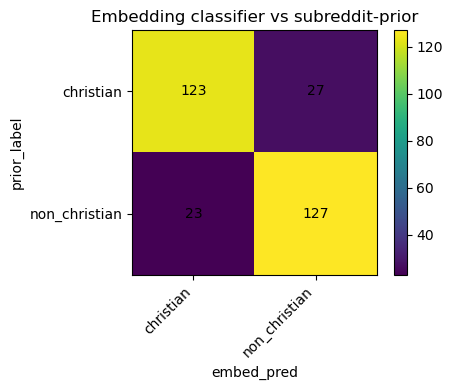


CROSS-ENCODER vs SUBREDDIT-PRIOR (unambiguous subs, subsample)


ce_pred,christian,non_christian
prior_label,,
christian,27,2
non_christian,19,12


Accuracy: 65.00%


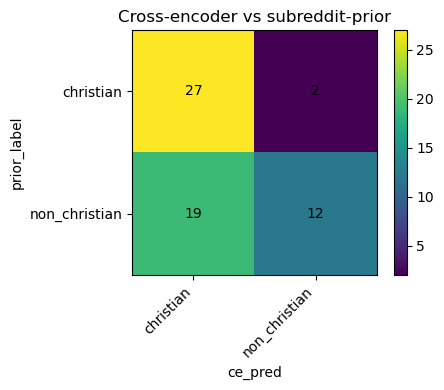


Embedding vs cross-encoder agreement (unambiguous subs, subsample): 68.33%

AMBIGUOUS SUBS: embedding classifier label distribution


embed_pred,christian,non_christian
subreddit,,
DebateReligion,47,103



Embedding vs cross-encoder agreement (ambiguous subs, subsample): 50.00%


embed_pred,christian,non_christian
ce_pred,,
christian,7,14
non_christian,1,8


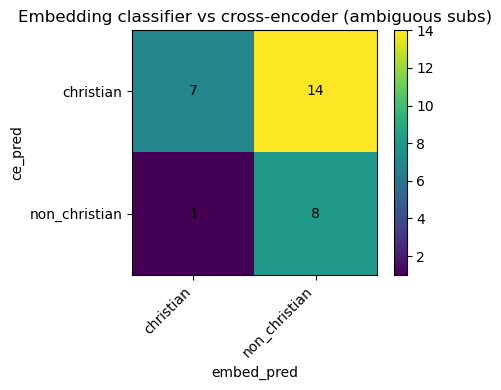

,subset,n,embed_vs_prior_acc,ce_vs_prior_acc,embed_vs_ce_agreement
0,unambiguous (subreddit-prior = gold),300,83.33%,65.00%,68.33%
1,ambiguous (no gold),150,--,--,50.00%


In [14]:
# ------------------------------------------------------------
# Phase 1 evaluation: embedding classifier vs cross-encoder vs subreddit-prior
# ------------------------------------------------------------

LABELS = ("christian", "non_christian")


def confusion(df, gold_col, pred_col):
    sub = df.dropna(subset=[gold_col, pred_col])
    cm = pd.crosstab(sub[gold_col], sub[pred_col], rownames=[gold_col], colnames=[pred_col], dropna=False)
    return cm.reindex(index=LABELS, columns=LABELS, fill_value=0)


def plot_confusion_heatmap(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm.values)

    ax.set_title(title)
    ax.set_xlabel(cm.columns.name or "predicted")
    ax.set_ylabel(cm.index.name or "gold")

    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm.index)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm.values[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()


print("EMBEDDING CLASSIFIER vs SUBREDDIT-PRIOR (unambiguous subs)")
cm_embed_prior = confusion(eval_unambiguous, "prior_label", "embed_pred")
display(cm_embed_prior)
acc_embed_prior = (eval_unambiguous["prior_label"] == eval_unambiguous["embed_pred"]).mean()
print(f"Accuracy: {acc_embed_prior:.2%}")
plot_confusion_heatmap(cm_embed_prior, "Embedding classifier vs subreddit-prior")

print("\nCROSS-ENCODER vs SUBREDDIT-PRIOR (unambiguous subs, subsample)")
ce_mask = eval_unambiguous["ce_pred"].notna()
cm_ce_prior = confusion(eval_unambiguous, "prior_label", "ce_pred")
display(cm_ce_prior)
acc_ce_prior = (eval_unambiguous.loc[ce_mask, "prior_label"] == eval_unambiguous.loc[ce_mask, "ce_pred"]).mean()
print(f"Accuracy: {acc_ce_prior:.2%}")
plot_confusion_heatmap(cm_ce_prior, "Cross-encoder vs subreddit-prior")

agree_embed_ce_unamb = (eval_unambiguous.loc[ce_mask, "embed_pred"] == eval_unambiguous.loc[ce_mask, "ce_pred"]).mean()
print(f"\nEmbedding vs cross-encoder agreement (unambiguous subs, subsample): {agree_embed_ce_unamb:.2%}")

print("\nAMBIGUOUS SUBS: embedding classifier label distribution")
display(eval_ambiguous.groupby("subreddit")["embed_pred"].value_counts().unstack(fill_value=0))

ce_mask_amb = eval_ambiguous["ce_pred"].notna()
agree_embed_ce_amb = (eval_ambiguous.loc[ce_mask_amb, "embed_pred"] == eval_ambiguous.loc[ce_mask_amb, "ce_pred"]).mean()
print(f"\nEmbedding vs cross-encoder agreement (ambiguous subs, subsample): {agree_embed_ce_amb:.2%}")

cm_embed_ce_amb = confusion(eval_ambiguous, "ce_pred", "embed_pred")
display(cm_embed_ce_amb)
plot_confusion_heatmap(cm_embed_ce_amb, "Embedding classifier vs cross-encoder (ambiguous subs)")

summary_df = pd.DataFrame([
    {
        "subset": "unambiguous (subreddit-prior = gold)",
        "n": len(eval_unambiguous),
        "embed_vs_prior_acc": acc_embed_prior,
        "ce_vs_prior_acc": acc_ce_prior,
        "embed_vs_ce_agreement": agree_embed_ce_unamb,
    },
    {
        "subset": "ambiguous (no gold)",
        "n": len(eval_ambiguous),
        "embed_vs_prior_acc": np.nan,
        "ce_vs_prior_acc": np.nan,
        "embed_vs_ce_agreement": agree_embed_ce_amb,
    },
])
display(summary_df.style.format({
    "embed_vs_prior_acc": "{:.2%}",
    "ce_vs_prior_acc": "{:.2%}",
    "embed_vs_ce_agreement": "{:.2%}",
}, na_rep="--"))

## Other ideas / future extensions

- **Validation-set bootstrapping**: use cross-encoder NLI predictions on a larger
  unlabeled sample to flag likely-mislabeled prototype posts for removal from the
  centroid computation (cheap automated cleanup, still no manual labeling).
- **Author-level aggregation**: classify at the author level (mean/centroid of
  recent post embeddings) rather than per-post, to reduce single-post noise -
  relevant if the binary classifier feeds into `GenerateScores.ipynb`-style
  author scoring.
- **Richer trajectory signal**: instead of a single scalar stance score, smooth
  the full embedding vector (or a low-dim PCA of it) over time with the same
  kernel-regression approach, then track distance/direction to the class
  centroids over time.